In [236]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

In [237]:
FONT_SIZE = 12
FONT_WEIGHT = 'bold'

In [249]:
# Change here and Run All
search_space = 'sss'
dataset = 'ImageNet16-120'


Memory Training

In [239]:
mem_train = pd.read_csv(f'{search_space}_history/{dataset}_Memory_training.csv')
mem_train

,Epoch,Batch,Train_loss,Val_loss
0,0,0,0.419497,325.538727
1,0,200,0.040507,43.190529
2,0,400,0.033281,34.127777
3,0,600,0.034768,32.252548
4,0,800,0.034036,30.943144
...,...,...,...,...
237,18,600,0.031645,28.954487
238,18,800,0.035701,28.714275
239,18,1000,0.030751,29.239065
240,18,1200,0.031533,30.064926


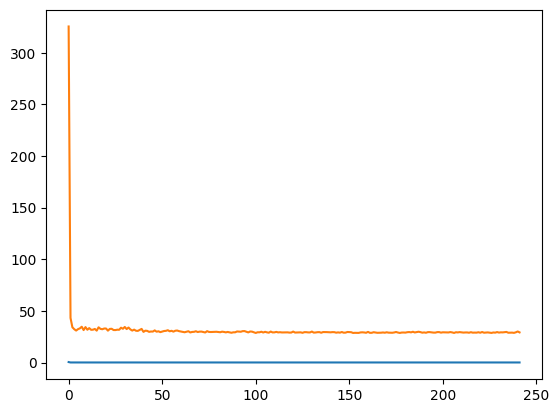

In [240]:
fig, ax = plt.subplots()
ax.plot(mem_train['Train_loss'])
ax.plot(mem_train['Val_loss'])
plt.show()

In [241]:
mem_test = pd.read_csv(f'{search_space}_history/{dataset}_Memory_test.csv')
mem_test['Predicted Accuracy'] = [float(x.strip('[]')) for x in mem_test['Predicted Accuracy']]
mem_test['Predicted Memory'] = [float(x.strip('[]')) for x in mem_test['Predicted Memory']]

FileNotFoundError: [Errno 2] No such file or directory: 'sss_history/ImageNet16-120_Memory_test.csv'

0.5707 0.0
0.7551


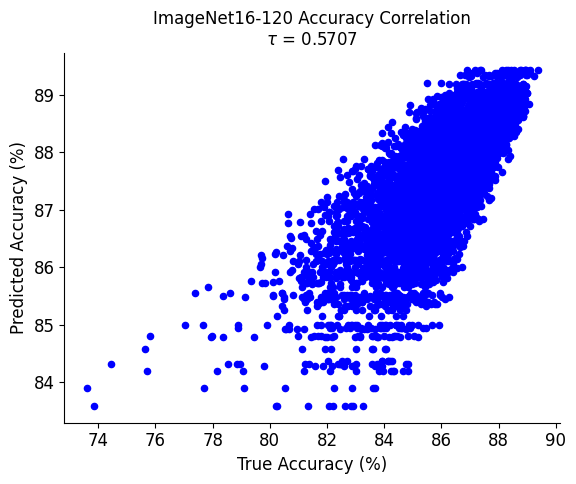

In [242]:
tau, p_value = kendalltau(mem_test['True Accuracy'], mem_test['Predicted Accuracy'])
print(f'{tau:.4f}', p_value)
correlation = np.corrcoef(mem_test['True Accuracy'], mem_test['Predicted Accuracy'])[0, 1]
print(f'{correlation:.4f}')

fig, ax = plt.subplots()
ax.scatter(mem_test['True Accuracy'], mem_test['Predicted Accuracy'], s=20, c='blue')

ax.set_xlabel('True Accuracy (%)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted Accuracy (%)', fontsize=FONT_SIZE)
ax.set_title(f'{dataset} Accuracy Correlation\n$\\tau$ = {tau:.4f}', fontsize=FONT_SIZE)

ax.tick_params(axis='both', which='major', labelsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

0.7721 0.0
0.8911


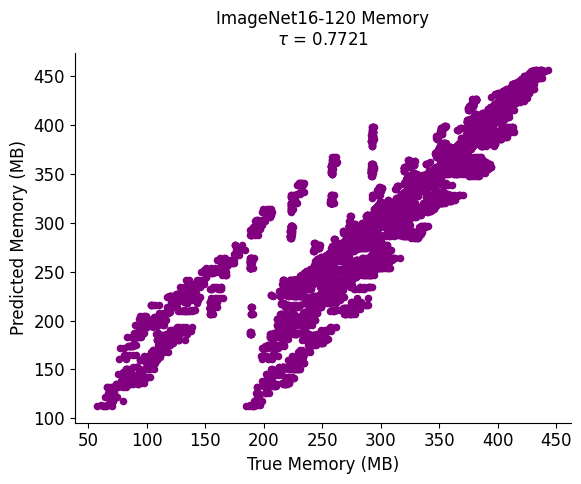

In [243]:
tau, p_value = kendalltau(mem_test['True Memory'], mem_test['Predicted Memory'])
print(f'{tau:.4f}', p_value)
correlation = np.corrcoef(mem_test['True Memory'], mem_test['Predicted Memory'])[0, 1]
print(f'{correlation:.4f}')

fig, ax = plt.subplots()
ax.scatter(mem_test['True Memory'], mem_test['Predicted Memory'], s=20, c='purple')

ax.set_xlabel('True Memory (MB)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted Memory (MB)', fontsize=FONT_SIZE)

ax.set_title(f'{dataset} Memory\n$\\tau$ = {tau:.4f}', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig(f'plots/{search_space}_{dataset}_memory.png', dpi=300, bbox_inches='tight')
plt.show()

Accuracy vs Memory - To be Done

0.7720543438460221 0.0
0.8911255812078155


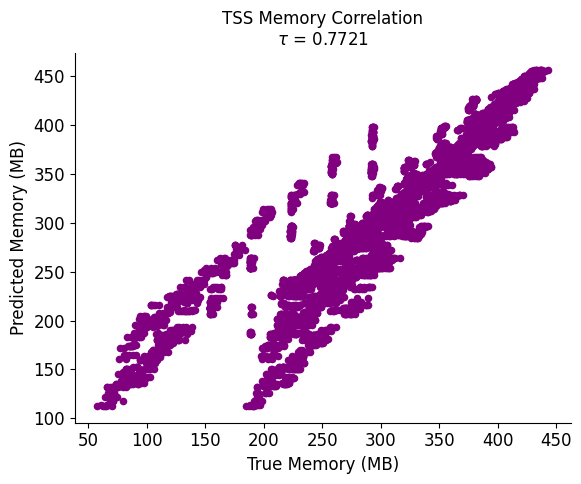

In [ ]:
tau, p_value = kendalltau(mem_test['True Memory'], mem_test['Predicted Memory'])
print(tau, p_value)
correlation = np.corrcoef(mem_test['True Memory'], mem_test['Predicted Memory'])[0, 1]
print(correlation)

fig, ax = plt.subplots()
ax.scatter(mem_test['True Memory'], mem_test['Predicted Memory'], s=20, c='purple')

ax.set_xlabel('True Memory (MB)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted Memory (MB)', fontsize=FONT_SIZE)

ax.set_title(f'TSS Memory Correlation\n$\\tau$ = {tau:.4f}', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

Latency Results

In [253]:
lat_train = pd.read_csv(f'{search_space}_history/{dataset}_Latency_training.csv')

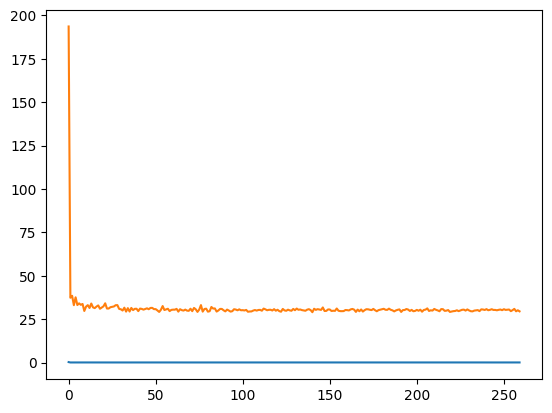

In [245]:
fig, ax = plt.subplots()
ax.plot(lat_train['Train_loss'])
ax.plot(lat_train['Val_loss'])
plt.show()

In [250]:
lat_test = pd.read_csv(f'{search_space}_history/{dataset}_Latency_test.csv')
lat_test['Predicted Accuracy'] = [float(x.strip('[]')) for x in lat_test['Predicted Accuracy']]
lat_test['Predicted Latency'] = [float(x.strip('[]')) for x in lat_test['Predicted Latency']]
len(lat_test)

6554

0.4755 0.0
0.6149


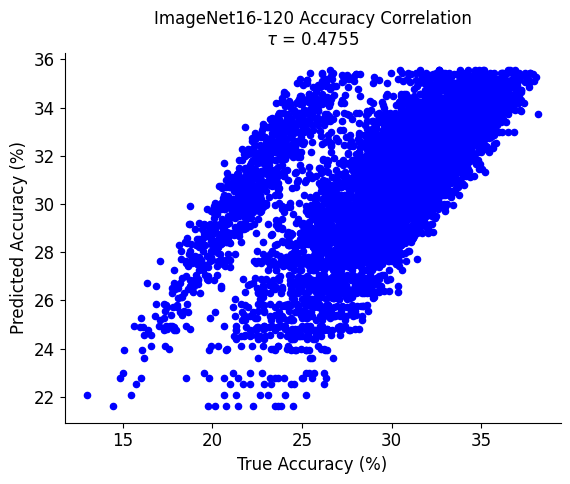

In [254]:
tau, p_value = kendalltau(lat_test['True Accuracy'], lat_test['Predicted Accuracy'])
print(f'{tau:.4f}', p_value)
correlation = np.corrcoef(lat_test['True Accuracy'], lat_test['Predicted Accuracy'])[0, 1]
print(f'{correlation:.4f}')

fig, ax = plt.subplots()
ax.scatter(lat_test['True Accuracy'], lat_test['Predicted Accuracy'], s=20, c='blue')

ax.set_xlabel('True Accuracy (%)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted Accuracy (%)', fontsize=FONT_SIZE)

ax.set_title(f'{dataset} Accuracy Correlation\n$\\tau$ = {tau:.4f}', fontsize=FONT_SIZE)

ax.tick_params(axis='both', which='major', labelsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

0.5739 0.0
0.7391


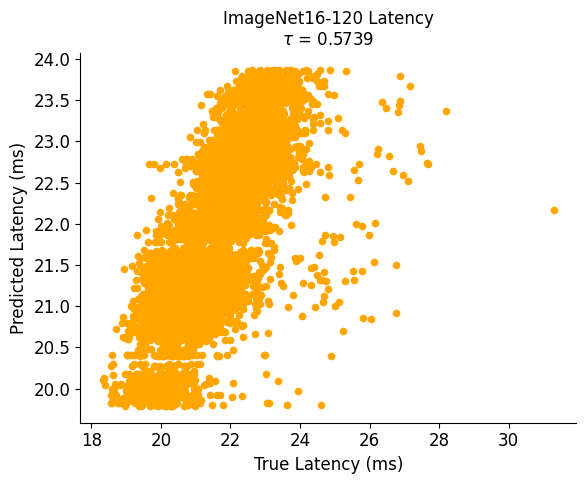

In [251]:
tau, p_value = kendalltau(lat_test['True Latency'], lat_test['Predicted Latency'])
print(f'{tau:.4f}', p_value)
correlation = np.corrcoef(lat_test['True Latency'], lat_test['Predicted Latency'])[0, 1]
print(f'{correlation:.4f}')

fig, ax = plt.subplots()
ax.scatter(lat_test['True Latency'], lat_test['Predicted Latency'], s=20, c='orange')
ax.set_xlabel('True Latency (ms)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted Latency (ms)', fontsize=FONT_SIZE)

ax.set_title(f'{dataset} Latency\n$\\tau$ = {tau:.4f}', fontsize=FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig(f'plots/{search_space}_{dataset}_latency.png', dpi=300, bbox_inches='tight')
plt.show()

Comparing Accuracy Alone For All Search Spaces

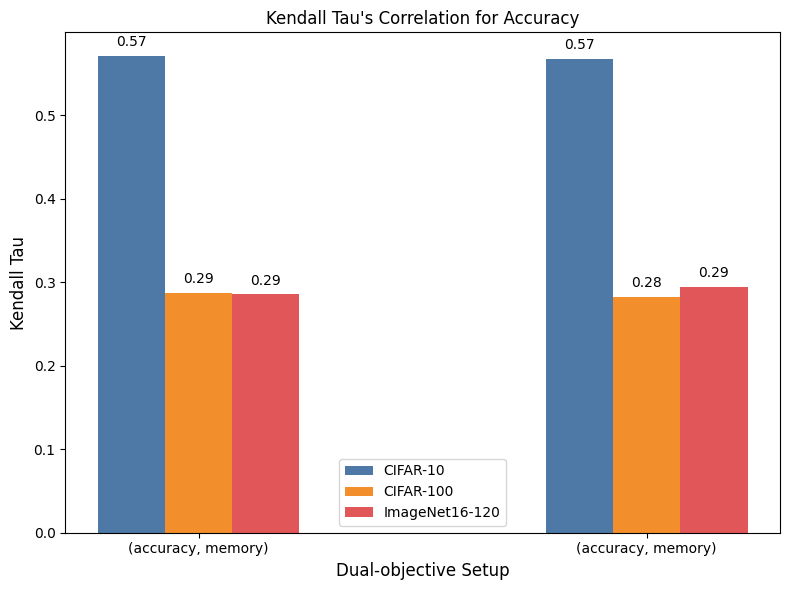

In [ ]:
categories = ['(accuracy, memory)', '(accuracy, memory)']
cifar10 = [0.5707, 0.5672]
cifar100 = [0.2869, 0.2819]
imagenet = [0.2853, 0.2948]

n_groups = len(categories)

index = np.arange(n_groups)
bar_width = 0.15

fig, ax = plt.subplots(figsize=(8, 6))

bars1 = ax.bar(index, cifar10, bar_width, label='CIFAR-10', color='#4e79a7') 
bars2 = ax.bar(index + bar_width, cifar100, bar_width, label='CIFAR-100', color='#f28e2b') 
bars3 = ax.bar(index + 2*bar_width, imagenet, bar_width, label='ImageNet16-120', color='#e15759')  

# Add value labels to bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),  # Offset label position
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# X and Y axis settings
ax.set_xlabel('Dual-objective Setup', fontsize=12)
ax.set_ylabel('Kendall Tau', fontsize=12)
ax.set_title("Kendall Tau's Correlation for Accuracy", fontsize=12)
ax.set_xticks(index + bar_width)
ax.set_xticklabels(categories)
ax.axhline(0, color='black', linewidth=0.5)  # Add baseline at y=0

# Add legend
ax.legend()

# Adjust layout and show
plt.tight_layout()
plt.savefig(f'plots/{search_space}_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
